# Mortgage Loan Limit Prediction — Regression Modeling

## Notebook Purpose

This notebook builds machine learning regression models to predict a borrower's maximum mortgage loan amount.

The target variable is:

- **Max Loan Amount (USD)**

The model uses borrower demographic, financial, credit, and loan-history features, including engineered variables created in 1_Mortgage_Loan_EDA.

This notebook includes:

1. Loading the engineered dataset
2. Preparing numerical and categorical features
3. Building preprocessing pipelines
4. Training multiple regression models
5. Evaluating models with MAE, RMSE, and R²
6. Performing cross-validation
7. Performing GridSearchCV hyperparameter tuning
8. Selecting the best model
9. Interpreting feature importance
10. Saving the final model for the forecasting notebook

## Modeling Objective

The main modeling question is:

> Can borrower characteristics be used to accurately predict maximum mortgage loan amount?

In [2]:
# Set Up

import os
import json
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
# Define file paths

PROCESSED_DATA_PATH = Path("outputs/processed_data/mortgage_loan_dataset_engineered.csv")
RAW_DATA_PATH = Path("mortgage_loan_dataset.csv")
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "model_reports"
MODELS_DIR = OUTPUT_DIR / "models"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(os.getcwd())

print("\nExpected engineered dataset:")
print(PROCESSED_DATA_PATH.resolve())

Current working directory:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example

Expected engineered dataset:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example/outputs/processed_data/mortgage_loan_dataset_engineered.csv


In [4]:
#OneHotEncoder Helper function
def make_onehot_encoder():
    """
    Newer versions of scikit-learn use sparse_output.
    Older versions use sparse.
    This helper makes the notebook compatible with both.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [5]:
def add_engineered_features(df):
    df = df.copy()
    
    df["Debt to Income Ratio"] = (
        df["Existing Monthly Debt (USD)"] * 12
    ) / df["Annual Income (USD)"]
    
    df["Available Annual Income (USD)"] = (
        df["Annual Income (USD)"]
        - df["Existing Monthly Debt (USD)"] * 12
    )
    
    df["Down Payment to Income Ratio"] = (
        df["Down Payment (USD)"]
        / df["Annual Income (USD)"]
    )
    
    df["Employment Stability Ratio"] = (
        df["Employment Years"]
        / df["Age"]
    )
    
    df["Loan Repayment Rate"] = (
        df["Loans Repaid"]
        / (df["Employment Years"] + 1)
    )
    
    df["Credit Score Category"] = pd.cut(
        df["Credit Score"],
        bins=[299, 579, 669, 739, 799, 850],
        labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
    )
    
    df["Income Category"] = pd.qcut(
        df["Annual Income (USD)"],
        q=4,
        labels=["Low", "Medium", "High", "Very High"],
        duplicates="drop"
    )
    
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

In [6]:
# Load dataset
if PROCESSED_DATA_PATH.exists():
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print("Loaded engineered dataset from Notebook 1.")
else:
    print("Engineered dataset not found. Loading raw dataset and creating engineered features.")
    df_raw = pd.read_csv(RAW_DATA_PATH)
    df = add_engineered_features(df_raw)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Loaded engineered dataset from Notebook 1.
Rows: 49,990
Columns: 21


,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD),Debt to Income Ratio,Available Annual Income (USD),Down Payment to Income Ratio,Employment Stability Ratio,Loan Repayment Rate,Credit Score Category,Income Category
0,Male,36,Yes,PhD,Software Engineer,13,"134,183.86",0.08,"101,706.78",682,"2,045.80",Urban,3,"498,842.67",0.18,"109,634.26",0.76,0.36,0.21,Good,High
1,Female,63,No,High School,Freelancer,37,"68,884.95",0.03,"46,324.29",823,804.73,Suburban,10,"536,232.53",0.14,"59,228.19",0.67,0.59,0.26,Excellent,Low
2,Female,33,Yes,PhD,Nurse,11,"76,396.27",0.03,"13,045.79",813,"1,050.54",Urban,0,"518,884.47",0.17,"63,789.79",0.17,0.33,0.00,Excellent,Low
3,Female,51,Yes,Bachelor's,Business Owner,29,"115,968.80",0.05,"60,388.40",752,904.08,Rural,2,"757,940.14",0.09,"105,119.84",0.52,0.57,0.07,Very Good,Medium
4,Male,53,Yes,Bachelor's,Nurse,27,"99,977.38",0.06,"54,838.14",728,"2,285.76",Rural,1,"283,110.21",0.27,"72,548.26",0.55,0.51,0.04,Good,Medium


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49990 entries, 0 to 49989
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         49990 non-null  object 
 1   Age                            49990 non-null  int64  
 2   Married                        49990 non-null  object 
 3   Education                      49990 non-null  object 
 4   Job                            49990 non-null  object 
 5   Employment Years               49990 non-null  int64  
 6   Annual Income (USD)            49990 non-null  float64
 7   Interest Rate                  49990 non-null  float64
 8   Down Payment (USD)             49990 non-null  float64
 9   Credit Score                   49990 non-null  int64  
 10  Existing Monthly Debt (USD)    49990 non-null  float64
 11  Area                           49990 non-null  object 
 12  Loans Repaid                   49990 non-null 

In [8]:
target = "Max Loan Amount (USD)"
print("Target variable:")
print(target)
print("\nTarget summary:")
display(df[target].describe())

Target variable:
Max Loan Amount (USD)

Target summary:


count      49,990.00
mean      663,419.15
std       312,681.14
min        26,142.54
25%       425,422.80
50%       623,243.47
75%       864,104.89
max     2,270,835.80
Name: Max Loan Amount (USD), dtype: float64

## Feature Selection

In [9]:
X = df.drop(columns=[target])
y = df[target]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Number of features:", X.shape[1])

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of features: 20

Numerical features:
['Age', 'Employment Years', 'Annual Income (USD)', 'Interest Rate', 'Down Payment (USD)', 'Credit Score', 'Existing Monthly Debt (USD)', 'Loans Repaid', 'Debt to Income Ratio', 'Available Annual Income (USD)', 'Down Payment to Income Ratio', 'Employment Stability Ratio', 'Loan Repayment Rate']

Categorical features:
['Gender', 'Married', 'Education', 'Job', 'Area', 'Credit Score Category', 'Income Category']


In [10]:
# Check for missing values

missing_after_engineering = X.isna().sum().sort_values(ascending=False)
missing_after_engineering[missing_after_engineering > 0]

Series([], dtype: int64)

## Train-Test Split
- 80% of the data is used for training
- 20% of the data is held out for final testing

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows: {X_test.shape[0]:,}")

Training rows: 39,992
Testing rows: 9,998


## Preprocessing
Transformations for numerical and categorical features.

In [12]:
# Build preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Employment Years',
                                  'Annual Income (USD)', 'Interest Rate',
                                  'Down Payment (USD)', 'Credit Score',
                                  'Existing Monthly Debt (USD)', 'Loans Repaid',
                                  'Debt to Income Ratio',
                                  'Available Annual Income (USD)',
                                  'Down Payment to Income Ratio',
                                  'Employment Stability Ratio',
                                  'Loan Repayment Rate']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Gender', 'Married', 'Education', 'Job',
                                  'Area', 'Credit Score Category',
                                  'Income Category'])])

## Evaluation Metrics
Three regression metrics are applied:

1. **Mean Absolute Error**
2. **Root Mean Squared Error**
3. **R²**

In [13]:
# Evaluation helper function
def evaluate_model(model_name, fitted_pipeline, X_test, y_test):
    predictions = fitted_pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    return {
        "Model": model_name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    }

## Baseline and Candidate Models

Multiple regression models are compared

1. **Linear Regression**  
2. **Ridge Regression**  
3. **Lasso Regression**  
4. **Random Forest Regressor**  
5. **Gradient Boosting Regressor**  

In [14]:
# Define candidate models
models = {
    "Linear Regression": LinearRegression(),
    
    "Ridge Regression": Ridge(alpha=1.0),
    
    "Lasso Regression": Lasso(
        alpha=0.001,
        max_iter=10000,
        random_state=RANDOM_STATE
    ),
    
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

models

{'Linear Regression': LinearRegression(),
 'Ridge Regression': Ridge(),
 'Lasso Regression': Lasso(alpha=0.001, max_iter=10000, random_state=42),
 'Random Forest Regressor': RandomForestRegressor(n_jobs=-1, random_state=42),
 'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)}

## Cross-Validation Setup


In [15]:
# Cross-validation setup
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)
cv

KFold(n_splits=5, random_state=42, shuffle=True)

In [16]:
# Train and evaluate all candidate models
model_results = []
fitted_models = {}
for model_name, estimator in models.items():
    print("=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )
    
    cv_rmse_scores = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    pipeline.fit(X_train, y_train)
    
    test_metrics = evaluate_model(
        model_name=model_name,
        fitted_pipeline=pipeline,
        X_test=X_test,
        y_test=y_test
    )
    
    test_metrics["CV RMSE Mean"] = cv_rmse_scores.mean()
    test_metrics["CV RMSE Std"] = cv_rmse_scores.std()
    
    model_results.append(test_metrics)
    fitted_models[model_name] = pipeline
    
    print(f"Test MAE:       ${test_metrics['Test MAE']:,.2f}")
    print(f"Test RMSE:      ${test_metrics['Test RMSE']:,.2f}")
    print(f"Test R²:        {test_metrics['Test R2']:.4f}")
    print(f"CV RMSE Mean:   ${test_metrics['CV RMSE Mean']:,.2f}")
    print(f"CV RMSE Std:    ${test_metrics['CV RMSE Std']:,.2f}")

Training model: Linear Regression
Test MAE:       $43,896.08
Test RMSE:      $59,689.93
Test R²:        0.9630
CV RMSE Mean:   $59,199.96
CV RMSE Std:    $608.54
Training model: Ridge Regression
Test MAE:       $43,895.65
Test RMSE:      $59,690.03
Test R²:        0.9630
CV RMSE Mean:   $59,199.92
CV RMSE Std:    $609.07
Training model: Lasso Regression


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.324e+12, tolerance: 3.147e+11
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.334e+12, tolerance: 3.139e+11
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.272e+12, toler

Test MAE:       $43,896.08
Test RMSE:      $59,689.93
Test R²:        0.9630
CV RMSE Mean:   $59,199.96
CV RMSE Std:    $608.54
Training model: Random Forest Regressor


Exception ignored in: <function ResourceTracker.__del__ at 0x111bf5800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105005800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x118069800>
Traceback (most recent call last

Test MAE:       $16,636.11
Test RMSE:      $23,285.39
Test R²:        0.9944
CV RMSE Mean:   $23,755.70
CV RMSE Std:    $329.92
Training model: Gradient Boosting Regressor
Test MAE:       $17,074.84
Test RMSE:      $22,583.55
Test R²:        0.9947
CV RMSE Mean:   $22,982.99
CV RMSE Std:    $360.96


In [17]:
# Model_Comparsion 
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values("Test RMSE").reset_index(drop=True)

results_df

,Model,Test MAE,Test RMSE,Test R2,CV RMSE Mean,CV RMSE Std
0,Gradient Boosting Regressor,"17,074.84","22,583.55",0.99,"22,982.99",360.96
1,Random Forest Regressor,"16,636.11","23,285.39",0.99,"23,755.70",329.92
2,Lasso Regression,"43,896.08","59,689.93",0.96,"59,199.96",608.54
3,Linear Regression,"43,896.08","59,689.93",0.96,"59,199.96",608.54
4,Ridge Regression,"43,895.65","59,690.03",0.96,"59,199.92",609.07


In [18]:
results_path = REPORTS_DIR / "model_comparison_results.csv"
results_df.to_csv(results_path, index=False)
print(f"Model comparison results saved to: {results_path}")

Model comparison results saved to: outputs/model_reports/model_comparison_results.csv


## Model Comparison Visualization
Lower RMSE and MAE are better.
Higher R² is better.

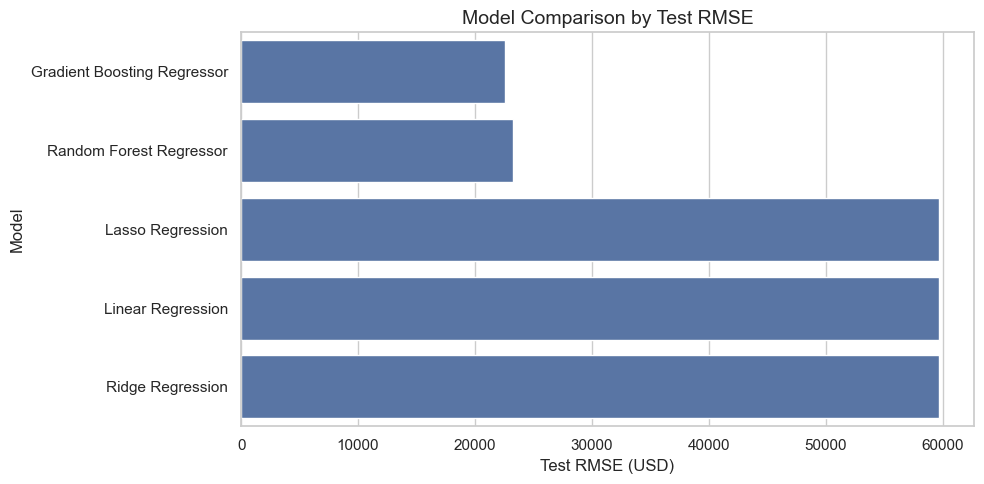

In [19]:
# Plot test comparison
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Test RMSE",
    y="Model"
)
plt.title("Model Comparison by Test RMSE", fontsize=14)
plt.xlabel("Test RMSE (USD)")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "11_model_comparison_rmse.png", dpi=300)
plt.show()

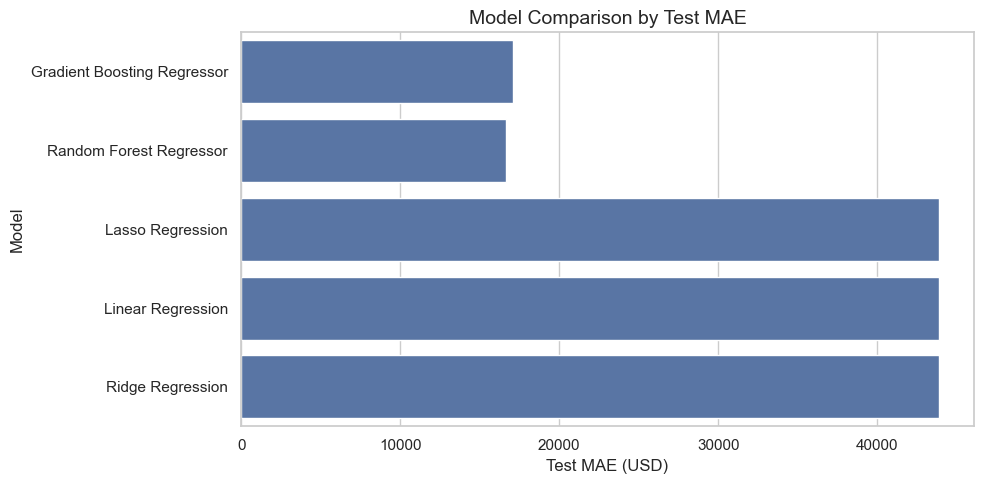

In [20]:
# Plot test MAE comparison
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Test MAE",
    y="Model"
)
plt.title("Model Comparison by Test MAE", fontsize=14)
plt.xlabel("Test MAE (USD)")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "12_model_comparison_mae.png", dpi=300)
plt.show()

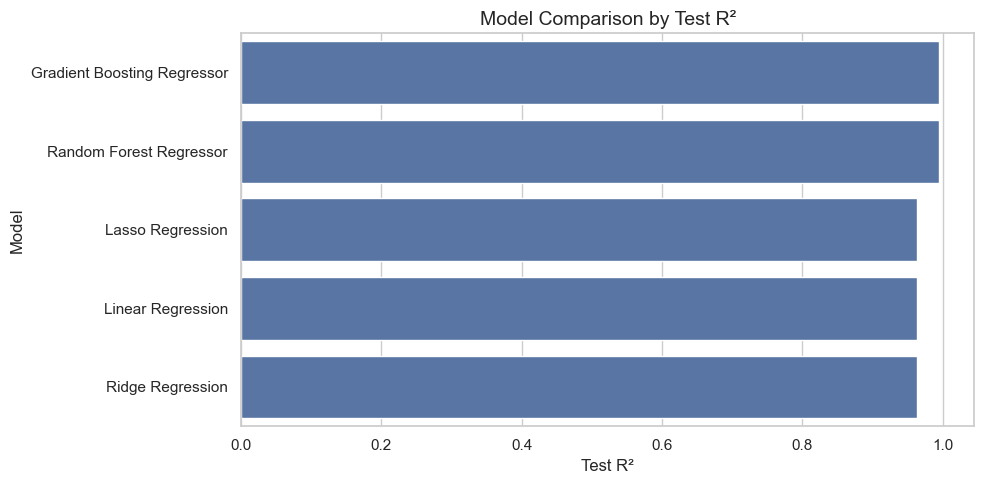

In [21]:
# Plot test R2 comparison
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Test R2",
    y="Model"
)
plt.title("Model Comparison by Test R²", fontsize=14)
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "13_model_comparison_r2.png", dpi=300)
plt.show()

## Hyperparameter Tuning with GridSearchCV


In [22]:
# Prepare training sample
grid_sample_size = min(20000, len(X_train))

X_train_grid = X_train.sample(
    n=grid_sample_size,
    random_state=RANDOM_STATE
)

y_train_grid = y_train.loc[X_train_grid.index]

print(f"GridSearchCV training sample size: {X_train_grid.shape[0]:,}")

GridSearchCV training sample size: 20,000


In [23]:
#Random Forest pipeline for GridSearchCV
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 3]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Employment '
                                                                          'Years',
                                                                          'Annual '
                                                                          'Income '
                                                                          '(USD)',
                                                                          'Interest '
                                                                          'Rate',
                                                                          'Down '
                                                                          'Payment '
                                                                          '(USD)',
                                                                          'Credit '
                                                                          'Score',
                                                                          'Existing '
                                                                          'Monthly '
                                                                          'Debt '
                                                                          '(USD)',
                                                                          'Loans '
                                                                          'Repaid',
                                                                          'Deb...
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Gender',
                                                                          'Married',
                                                                          'Education',
                                                                          'Job',
                                                                          'Area',
                                                                          'Credit '
                                                                          'Score '
                                                                          'Category',
                                                                          'Income '
                                                                          'Category'])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, None],
                         'model__min_samples_leaf': [1, 3],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [ ]:
# Run GridSearchCV
grid_search.fit(X_train_grid, y_train_grid)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation RMSE:")
print(f"${-grid_search.best_score_:,.2f}")

In [ ]:
# Fit tuned Random Forest on full training set

tuned_rf_model = grid_search.best_estimator_

tuned_rf_model.fit(X_train, y_train)

tuned_rf_metrics = evaluate_model(
    model_name="Tuned Random Forest Regressor",
    fitted_pipeline=tuned_rf_model,
    X_test=X_test,
    y_test=y_test
)

tuned_rf_metrics

In [ ]:
tuned_results_df = pd.DataFrame([tuned_rf_metrics])

final_results_df = pd.concat(
    [results_df, tuned_results_df],
    ignore_index=True
).sort_values("Test RMSE").reset_index(drop=True)

final_results_df

In [ ]:
final_results_path = REPORTS_DIR / "final_model_comparison_results.csv"

final_results_df.to_csv(final_results_path, index=False)

print(f"Final model comparison results saved to: {final_results_path}")

## Final Model Selection

In [ ]:
best_model_name = final_results_df.iloc[0]["Model"]

if best_model_name == "Tuned Random Forest Regressor":
    best_model = tuned_rf_model
else:
    best_model = fitted_models[best_model_name]

best_model_metrics = final_results_df.iloc[0].to_dict()

print("Final selected model:")
print(best_model_name)

print("\nFinal model performance:")
for key, value in best_model_metrics.items():
    if key == "Model":
        print(f"{key}: {value}")
    elif "R2" in key:
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: ${value:,.2f}")

## Final Model Diagnostics

The following diagnostic plots evaluate how well the final model predicts maximum loan amount.

The plots include:

1. Predicted vs. actual loan amount
2. Residual errors
3. Residual distribution

A strong model should have predicted values close to the actual values and residuals centered around zero.

In [ ]:
# Generate predictions with final model
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

prediction_df = pd.DataFrame({
    "Actual Max Loan Amount": y_test,
    "Predicted Max Loan Amount": y_pred,
    "Residual": residuals
})

prediction_df.head()

In [ ]:
# Predicted vs actual plot
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=prediction_df["Actual Max Loan Amount"],
    y=prediction_df["Predicted Max Loan Amount"],
    alpha=0.35
)

min_value = min(
    prediction_df["Actual Max Loan Amount"].min(),
    prediction_df["Predicted Max Loan Amount"].min()
)

max_value = max(
    prediction_df["Actual Max Loan Amount"].max(),
    prediction_df["Predicted Max Loan Amount"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="red"
)

plt.title("Predicted vs Actual Max Loan Amount", fontsize=14)
plt.xlabel("Actual Max Loan Amount (USD)")
plt.ylabel("Predicted Max Loan Amount (USD)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "14_predicted_vs_actual.png", dpi=300)
plt.show()

In [ ]:
# Residual plot
plt.figure(figsize=(10, 5))

sns.scatterplot(
    x=prediction_df["Predicted Max Loan Amount"],
    y=prediction_df["Residual"],
    alpha=0.35
)

plt.axhline(0, linestyle="--", color="red")

plt.title("Residual Plot", fontsize=14)
plt.xlabel("Predicted Max Loan Amount (USD)")
plt.ylabel("Residual Error (Actual - Predicted)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "15_residual_plot.png", dpi=300)
plt.show()

In [ ]:
# Residual distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    prediction_df["Residual"],
    bins=50,
    kde=True
)
plt.title("Distribution of Residual Errors", fontsize=14)
plt.xlabel("Residual Error (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "16_residual_distribution.png", dpi=300)
plt.show()

## Feature Importance

Identify the impartance of each feature to explain which borrower characteristics most influence the final predictions.

In [ ]:
# Extract feature names after preprocessing
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_estimator = best_model.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()
print(f"Number of transformed features: {len(feature_names)}")
feature_names[:20]

In [ ]:
if hasattr(fitted_estimator, "feature_importances_"):
    importance_values = fitted_estimator.feature_importances_
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    }).sort_values("Importance", ascending=False)

elif hasattr(fitted_estimator, "coef_"):
    coefficients = np.ravel(fitted_estimator.coef_)
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Importance": np.abs(coefficients)
    }).sort_values("Importance", ascending=False)

else:
    importance_df = pd.DataFrame({
        "Feature": ["Feature importance not available"],
        "Importance": [np.nan]
    })

importance_df.head(20)

In [ ]:
importance_df["Readable Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

importance_df.head(20)

In [ ]:
feature_importance_path = REPORTS_DIR / "feature_importance.csv"
importance_df.to_csv(feature_importance_path, index=False)
print(f"Feature importance saved to: {feature_importance_path}")

In [ ]:
top_features = importance_df.head(20)
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Readable Feature"
)

plt.title("Top 20 Feature Importances", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "17_feature_importance.png", dpi=300)
plt.show()

## Save Final Model and Data for 3_Forecasting _ Projection

In [ ]:
# Save final model
model_path = MODELS_DIR / "best_mortgage_loan_model.joblib"
dump(best_model, model_path)
print(f"Best model saved to: {model_path}")

In [ ]:
# Save model data
category_options = {}
for col in categorical_features:
    category_options[col] = sorted(X[col].dropna().astype(str).unique().tolist())

model_metadata = {
    "target": target,
    "best_model_name": best_model_name,
    "feature_columns": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "category_options": category_options,
    "best_model_metrics": {
        key: float(value) if isinstance(value, (int, float, np.number)) else value
        for key, value in best_model_metrics.items()
    }
}

metadata_path = MODELS_DIR / "model_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=4)

print(f"Model metadata saved to: {metadata_path}")

## Modeling Findings

In [ ]:
print("=" * 80)
print("NOTEBOOK 2 FINAL SUMMARY")
print("=" * 80)

print(f"Final selected model: {best_model_name}")

print("\nFinal model performance:")
print(f"Test MAE:  ${best_model_metrics['Test MAE']:,.2f}")
print(f"Test RMSE: ${best_model_metrics['Test RMSE']:,.2f}")
print(f"Test R²:   {best_model_metrics['Test R2']:.4f}")

print("\nTop 10 important features:")
display(importance_df[["Readable Feature", "Importance"]].head(10))

print("\n saved")

## Summary

This notebook completed:

- Loaded engineered dataset from 1_Mortgage_Loan_EDA
- Defined features and target variable
- Built preprocessing pipelines for numerical and categorical variables
- Split the data into training and testing sets
- Trained multiple regression models
- Evaluated models using MAE, RMSE, and R²
- Performed 5-fold cross-validation
- Tuned a Random Forest model using GridSearchCV
- Selected the final model based on test RMSE
- Created diagnostic plots
- Generated feature importance analysis
- Saved the final model and data for 3_Forecasting _ Projection